In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.inspection import PartialDependenceDisplay

In [3]:
enron = pd.read_csv('../data/enron_model_ft.csv')

/var/folders/4y/0t9f134178bbfj5m299wl_7h0000gn/T/ipykernel_45375/1053813020.py:1: DtypeWarning: Columns (2,4,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  enron = pd.read_csv('../data/enron_model_ft.csv')


In [40]:
enron.head()

,Unnamed: 0,EmailSend,EmailReply,SubjectSend,SubjectReply,From,To,DateSend,DateReply,Context,...,avg_word_length,stop_word_ratio,response_time,Response_Within_15_Mins,Response_Within_60_Mins,Response_Within_120_Mins,Response_Within_3_hours,has_question,exclamation_count,urgency_bucket
0,0,"Nikki, Thanks for the note and I hope your doi...",Hello hello! I was so worried that I had said ...,Portland,Re: Portland,bill.williams@enron.com,-nikole@excite.com,2001-06-18 22:44:00,2001-06-19 15:49:00,NaN,...,3.920078,0.547758,1025.0,0,0,0,0,1,1,same_day
1,1,Jim Lokay Sales Representative British Parts I...,HI,Call when you receive this (no rush),RE: Call when you receive this (no rush),548@britishparts.com,michelle.lokay@enron.com,2002-03-19 08:30:00,2002-03-19 08:34:00,NaN,...,5.538462,0.000000,4.0,1,1,1,1,0,0,instant
2,2,Congratulations! Have a good sleep.,Just woke up...thnx for your note. I believe t...,Thanks and,Re: Thanks and,louise.kitchen@enron.com,8774754543@skytel.com,2002-01-15 12:30:00,2002-01-15 16:29:00,NaN,...,5.800000,0.400000,239.0,0,0,0,0,0,1,same_day
3,3,Test,Call back : Geir.Solberg@enron.com|Test|Test,Test,Re: Test,geir.solberg@enron.com,8776519147@skytel.com,2002-01-19 10:55:00,2002-01-19 10:56:00,NaN,...,4.000000,0.000000,1.0,1,1,1,1,0,0,instant
4,4,We are dropping a lot of marketers. It would b...,As shankman would say 'working ya',Marketers,RE: Marketers,8777865122@skytel.com,louise.kitchen@enron.com,2002-01-21 15:30:00,2002-01-21 15:44:00,NaN,...,3.187500,0.500000,14.0,1,1,1,1,0,0,fast


In [6]:
enron.columns

Index(['Unnamed: 0', 'EmailSend', 'EmailReply', 'SubjectSend', 'SubjectReply',
       'From', 'To', 'DateSend', 'DateReply', 'Context',
       'Response_Within_30_Mins', 'HourSent', 'DaySent', 'IsWeekend',
       'Responded', 'EmailSend_Token_Count', 'syllable_count',
       'avg_word_length', 'stop_word_ratio', 'response_time',
       'Response_Within_15_Mins', 'Response_Within_60_Mins',
       'Response_Within_120_Mins', 'Response_Within_3_hours', 'has_question',
       'exclamation_count'],
      dtype='object')

In [36]:
def bucket_urgency(minutes):
    if pd.isna(minutes):
        return 'ghosted'
    elif minutes < 5:
        return 'instant'
    elif minutes < 15:
        return 'fast'
    elif minutes < 24*60:
        return 'same_day'
    else:
        return 'next_day'

enron['urgency_bucket'] = enron['response_time'].apply(bucket_urgency)
enron['urgency_bucket'].value_counts()

urgency_bucket
ghosted     344643
same_day      8677
instant       2977
fast          2346
next_day      1108
Name: count, dtype: int64

In [37]:
X = enron[variables]  # your existing numeric_features + categorical_features
y = enron['urgency_bucket']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=321, stratify=y
)

nn_pipe = Pipeline(steps=[
    ('prep', preprocessor),  # reuse your existing ColumnTransformer
    ('nn', MLPClassifier(hidden_layer_sizes=(32, 16),
                          activation='relu',
                          random_state=321,
                          max_iter=500))
]).fit(X_train, y_train)

In [38]:
y_pred = nn_pipe.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[    0   576     0     0    11]
 [    0 86151     0     0    10]
 [    0   740     0     0     4]
 [    0   273     1     0     3]
 [    0  2152     1     0    16]]
              precision    recall  f1-score   support

        fast       0.00      0.00      0.00       587
     ghosted       0.96      1.00      0.98     86161
     instant       0.00      0.00      0.00       744
    next_day       0.00      0.00      0.00       277
    same_day       0.36      0.01      0.01      2169

    accuracy                           0.96     89938
   macro avg       0.26      0.20      0.20     89938
weighted avg       0.93      0.96      0.94     89938



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


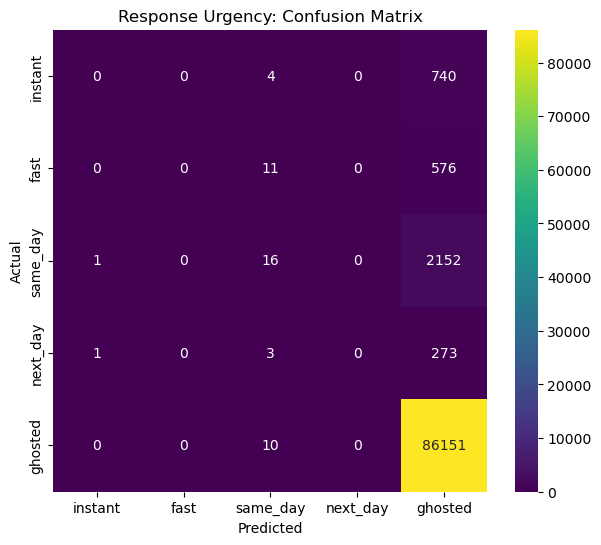

In [39]:
labels = ['instant', 'fast', 'same_day', 'next_day', 'ghosted']
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Response Urgency: Confusion Matrix')
plt.show()

In [52]:
import networkx as nx
import matplotlib.pyplot as plt

# Build the full directed graph
G = nx.from_pandas_edgelist(enron, 'From', 'To', edge_attr='response_time',
                             create_using=nx.DiGraph())

print(f"Full graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Full graph: 62630 nodes, 82902 edges
